# EDA notebook for Minecraft texture dataset

## Import and setup

In [119]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [120]:
plt.style.use("ggplot")

LABELS_PATH = Path("../data/processed/labels.csv")

df = pd.read_csv(LABELS_PATH)
KIND_MAP = {"blocks": "block", "items": "item"}
df["pack_clean"] = df["pack"].astype(str).str.strip().str.lower()
df["kind_clean"] = df["kind"].astype(str).str.strip().str.lower().replace(KIND_MAP)
default_df = df[df["pack"] == "default"].copy()
other_df = df[df["pack"] != "default"].copy()

## General dataset overview

In [121]:
df.head()

,file,labels,pack,style,kind,pack_clean,kind_clean
0,alexs_mobs-block_banana_peel.png,"vanilla-consistent,wildlife-expansion,realisti...",alexs_mobs,vanilla,block,alexs_mobs,block
1,alexs_mobs-block_banana_peel_bottom.png,"vanilla-consistent,wildlife-expansion,realisti...",alexs_mobs,vanilla,block,alexs_mobs,block
2,alexs_mobs-block_banana_peel_top.png,"vanilla-consistent,wildlife-expansion,realisti...",alexs_mobs,vanilla,block,alexs_mobs,block
3,alexs_mobs-block_banana_slug_slime_block.png,"vanilla-consistent,wildlife-expansion,realisti...",alexs_mobs,vanilla,block,alexs_mobs,block
4,alexs_mobs-block_banana_slug_slime_block_bubbl...,"vanilla-consistent,wildlife-expansion,realisti...",alexs_mobs,vanilla,block,alexs_mobs,block


In [122]:
print("Total images:", len(other_df))
print("Number of packs:", other_df["pack"].nunique())
print("Number of styles:", other_df["style"].nunique())
print("Number of kinds:", other_df["kind"].nunique())

Total images: 30083
Number of packs: 29
Number of styles: 20
Number of kinds: 8


## General counts

### mods vs texture packs

In [123]:
texture_packs = {
    "jolicraft",
    "misa",
    "super_cute",
    "festive_mashup",
    "halloween_mashup",
    "overgrown",
    "overite",
    "rappenem",
    "candy",
    "ashen",
}

other_df["category"] = other_df["pack"].apply(
    lambda x: "Texture Packs" if x in texture_packs else "Mods"
)

counts = other_df["category"].value_counts()
percentages = counts / counts.sum() * 100

In [124]:
print("Category distribution:")
for category, count in counts.items():
    percentage = percentages[category]
    print(f"{category}: {count} images ({percentage:.2f}%)")

Category distribution:
Texture Packs: 21788 images (72.43%)
Mods: 8295 images (27.57%)


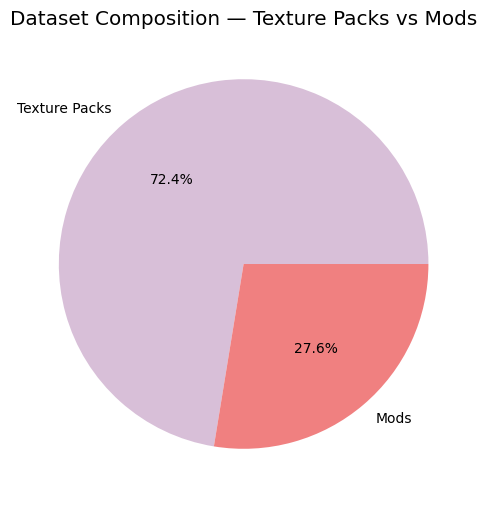

In [125]:
plt.figure(figsize=(6, 6))

plt.pie(
    percentages.values,
    labels=percentages.index,
    autopct="%1.1f%%",
    colors=["thistle", "lightcoral"],
)

plt.title("Dataset Composition — Texture Packs vs Mods")
plt.show()

### Images per pack

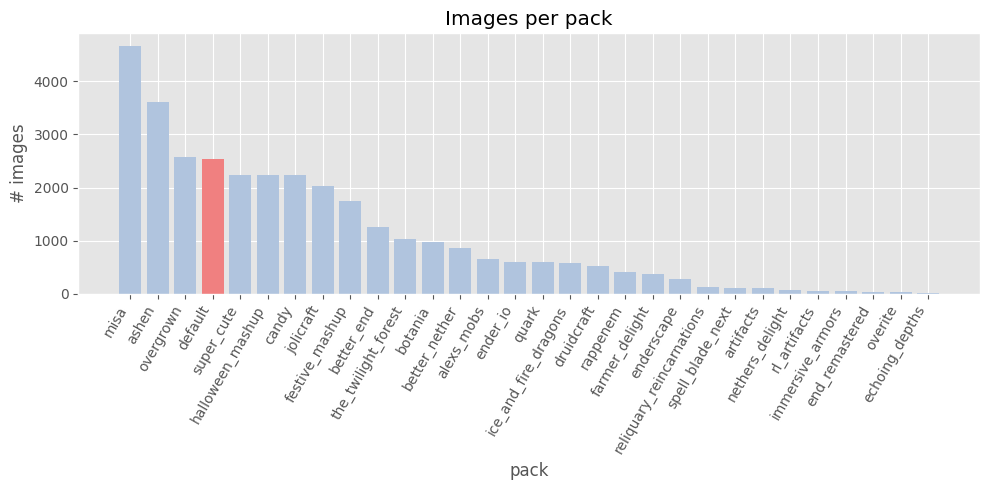

In [126]:
images_per_pack = df.groupby("pack_clean").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

colors = [
    "lightcoral" if pack == "default" else "lightsteelblue"
    for pack in images_per_pack.index
]

plt.bar(images_per_pack.index, images_per_pack.values, color=colors)

plt.xticks(rotation=60, ha="right")
plt.title("Images per pack")
plt.xlabel("pack")
plt.ylabel("# images")

plt.tight_layout()
plt.show()

### Images per kind

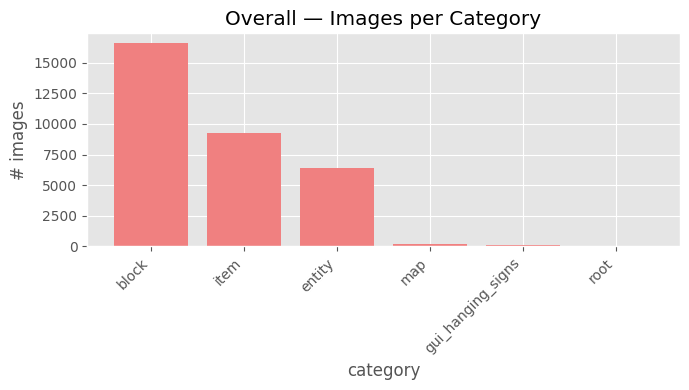

In [127]:
images_per_kind = df.groupby("kind_clean").size().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(images_per_kind.index, images_per_kind.values, color="lightcoral")
plt.xticks(rotation=45, ha="right")
plt.title("Overall — Images per Category")
plt.xlabel("category")
plt.ylabel("# images")
plt.tight_layout()
plt.show()

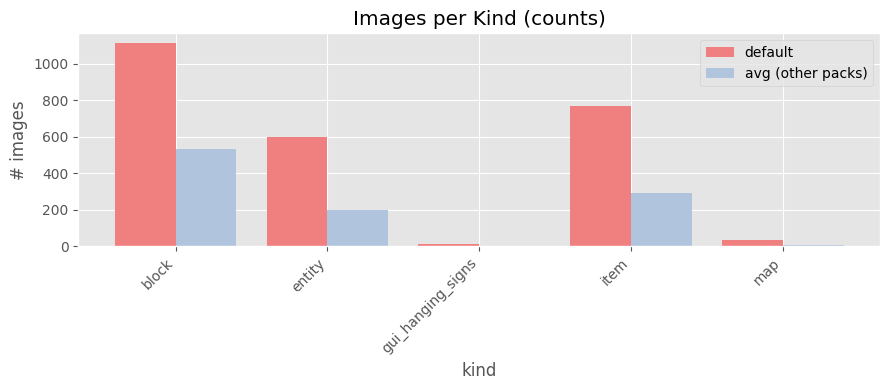

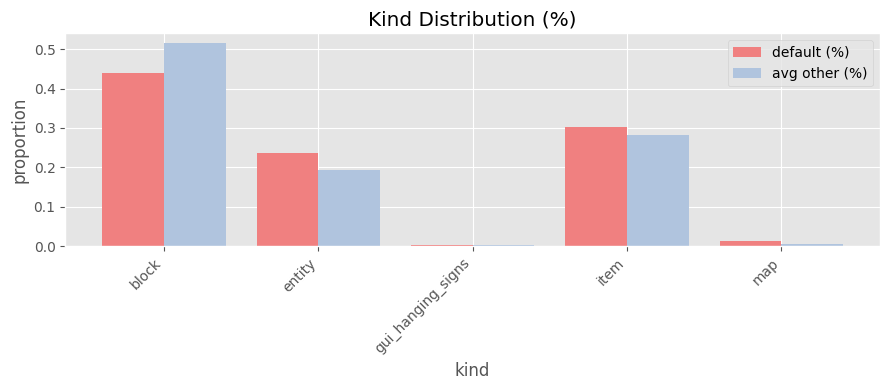

In [ ]:
default_df_filtered = default_df[default_df["kind_clean"] != "root"]
other_df_filtered = other_df[other_df["kind_clean"] != "root"]

default_counts = default_df_filtered.groupby("kind_clean").size()

other_counts = (
    other_df_filtered.groupby(["pack_clean", "kind_clean"]).size().unstack(fill_value=0)
)

avg_other_counts = other_counts.mean()

all_kinds = sorted(set(default_counts.index).union(set(avg_other_counts.index)))
default_counts = default_counts.reindex(all_kinds, fill_value=0)
avg_other_counts = avg_other_counts.reindex(all_kinds, fill_value=0)

# Counts Plot
plt.figure(figsize=(9, 4))
x = np.arange(len(all_kinds))
w = 0.4

plt.bar(x - w / 2, default_counts.values, width=w, label="default", color="lightcoral")
plt.bar(
    x + w / 2,
    avg_other_counts.values,
    width=w,
    label="avg (other packs)",
    color="lightsteelblue",
)

plt.xticks(x, all_kinds, rotation=45, ha="right")
plt.title("Images per category (counts)")
plt.xlabel("category")
plt.ylabel("# images")
plt.legend()
plt.tight_layout()
plt.show()

# Percentage Plot
default_pct = default_counts / default_counts.sum()
avg_other_pct = avg_other_counts / avg_other_counts.sum()

plt.figure(figsize=(9, 4))
plt.bar(x - w / 2, default_pct.values, width=w, label="default (%)", color="lightcoral")
plt.bar(
    x + w / 2,
    avg_other_pct.values,
    width=w,
    label="avg other (%)",
    color="lightsteelblue",
)

plt.xticks(x, all_kinds, rotation=45, ha="right")
plt.title("Category distribution (%)")
plt.xlabel("category")
plt.ylabel("proportion")
plt.legend()
plt.tight_layout()
plt.show()

## Keywords

In [92]:
def split_labels(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(",") if x.strip()]

In [99]:
other_df["labels_list"] = other_df["labels"].apply(split_labels)

unique_keywords_per_pack = (
    other_df.groupby("pack")["labels_list"]
    .apply(lambda lists: len({k for sublist in lists for k in sublist}))
    .sort_values(ascending=False)
)

unique_keywords_per_pack.head()

pack
the_twilight_forest         13
echoing_depths              12
ice_and_fire_dragons        12
ender_io                    12
reliquary_reincarnations    11
Name: labels_list, dtype: int64

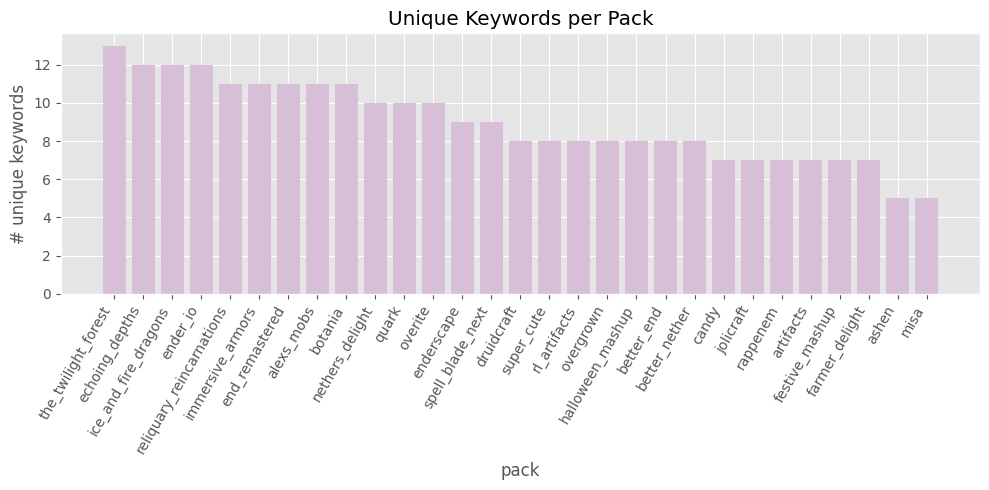

In [94]:
plt.figure(figsize=(10, 5))
plt.bar(
    unique_keywords_per_pack.index, unique_keywords_per_pack.values, color="thistle"
)

plt.xticks(rotation=60, ha="right")
plt.title("Unique Keywords per Pack")
plt.xlabel("pack")
plt.ylabel("# unique keywords")

plt.tight_layout()
plt.show()

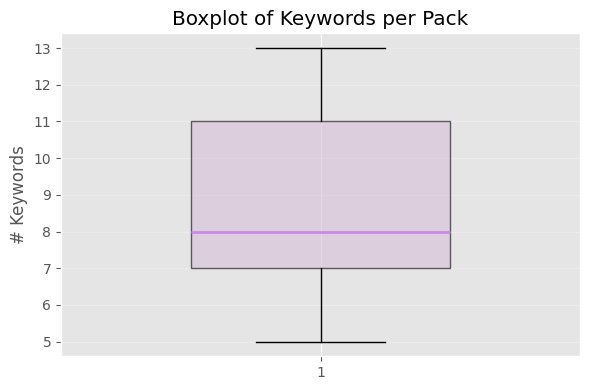

In [95]:
plt.figure(figsize=(6, 4))

box = plt.boxplot(unique_keywords_per_pack.values, patch_artist=True, widths=0.5)

for patch in box["boxes"]:
    patch.set_facecolor("thistle")
    patch.set_alpha(0.6)

for median in box["medians"]:
    median.set_color("#C68BEB")
    median.set_linewidth(2)

plt.title("Boxplot of Keywords per Pack")
plt.ylabel("# Keywords")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

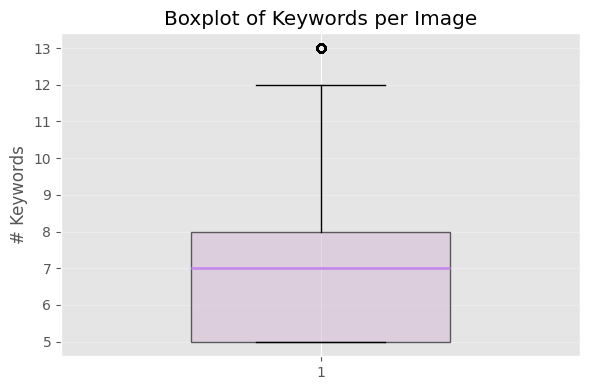

In [96]:
plt.figure(figsize=(6, 4))
other_df["n_keywords_image"] = other_df["labels_list"].apply(len)
box = plt.boxplot(other_df["n_keywords_image"].values, patch_artist=True, widths=0.5)

for patch in box["boxes"]:
    patch.set_facecolor("thistle")
    patch.set_alpha(0.6)

for median in box["medians"]:
    median.set_color("#C68BEB")
    median.set_linewidth(2)

plt.title("Boxplot of Keywords per Image")
plt.ylabel("# Keywords")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:
all_keywords = [k for sublist in other_df["labels_list"] for k in sublist]

unique_keywords = set(all_keywords)

print("Total unique keywords:", len(unique_keywords))

Total unique keywords: 190


In [98]:
keyword_counts = Counter(all_keywords)

keyword_df = pd.DataFrame(
    keyword_counts.items(), columns=["keyword", "count"]
).sort_values(by="count", ascending=False)

keyword_df.head(15)

,keyword,count
48,colorful,6909
11,fantasy,6563
50,playful,6493
2,realistic,5326
22,medieval,5253
133,detailed,5086
146,cute,4814
134,natural colors,4670
136,subtle shading,4670
135,soft lighting,4670
